In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
df = pd.read_csv("df_assignment.csv.gz", )


focus_crime = [
    "larceny theft",
    "motor vehicle theft",
    "robbery",
    "assault",
    "drug offense",
    "weapons offense",
    "vandalism",
    "suicide",
]


Assignment 1.1: Temporal Overview
Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

Draws from: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

Using your combined dataset (2003–present), plot the total number of incidents per year for each of your Personal Focus Crimes. Display at least the years 2003–2025.
Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

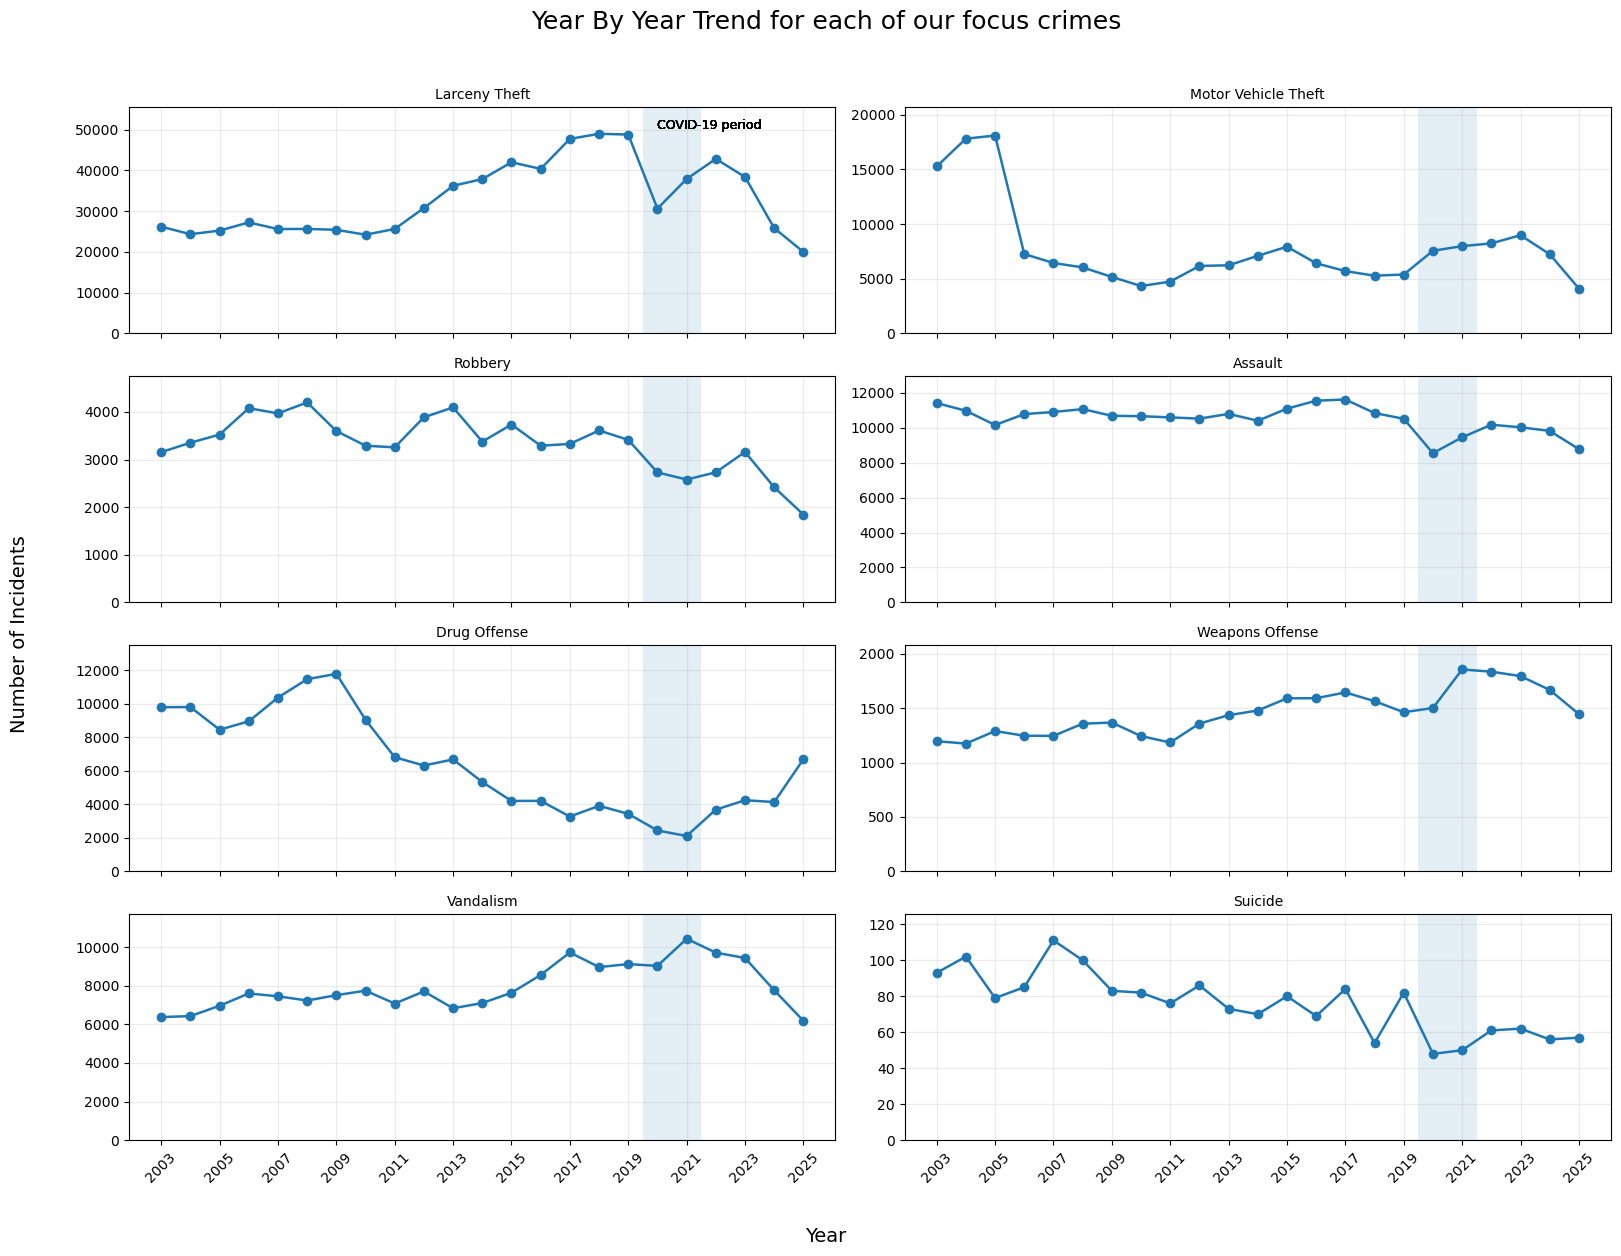

In [25]:

counts = (
    df[df["category"].isin(focus_crime)]
    .groupby(["year", "category"])
    .size()
    .unstack("category", fill_value=0)
    .sort_index()
)

years_to_label = [2003, 2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019 , 2021, 2023, 2025]

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)


axes = np.array(axes).reshape(4, 2)

for idx, crime in enumerate(focus_crime):
    r, c = divmod(idx, 2)
    ax = axes[r, c]

    y = counts.get(crime, 0)

    ax.plot(counts.index, y.values, marker="o", linewidth=1.8)
    ax.set_title(crime.title(), fontsize=10)
    ax.grid(True, alpha=0.25)

    ax.axvspan(2019.5, 2021.5, alpha=0.12)
    axes[0, 0].text(
        2020, 0.95, "COVID-19 period",
        transform=axes[0, 0].get_xaxis_transform(),
        fontsize=9, va="top"
    )

    ax.set_xticks(years_to_label)
    ax.tick_params(axis="x", rotation=45)

    ax.set_ylim(bottom=0, ymax=ax.get_ylim()[1] * 1.1)

for j in range(len(focus_crime), axes.size):
    axes.flat[j].set_visible(False)

fig.supxlabel("Year" , fontsize=14, y=-0.01)
fig.supylabel("Number of Incidents", fontsize=14, x=-0.01)
fig.suptitle("Year By Year Trend for each of our focus crimes",y=1.02, fontsize=18)

plt.tight_layout()
plt.show()


The above plot show the evolutuion of each of our chosen focus crimes from 2003 to 2025. We can see that there is no significant overall trend that spans clearly across all the different types of crime. However, there are some different tendencies for different categories. It is for example interesting to look at what effect Covid-19 had on crime in San Francisco. From the plot we can see that some types of crime such as larceny/theft and assault had a drastic reduction from 2019 to 2020 indicating an effect from covid-19. This also makes logically sense in a way that if fewer people are less outside on the street or at bars in the evening,, then the chance of assault or theft is also likely to drop. 

Another interesting trend that might also be Covid related is that we can see that drug offense was on a steady decline from 2009 to 2021, but when the world moved out of covid isolation this trend seems to have turned and it has been increasing every since. This could be Covid related, but it could also be due to other factors, as it is also not clear to us why drug offense started to decline like this in the first place.

The last interesting thing we see in the plot is that there is a significant drop in motor vehicle theft from 2005 to 2006 according to our data this type of crime got less that halved during this period. The most likely explanation to this is that it is not actually reflecting a chance in the real world but a change in how they report motor vehicle theft. This highlights an important lesson in data analysis. datasets can contain structural breaks or inconsistencies, and apparent trends should be interpreted cautiously rather than taken at face value.